<a href="https://colab.research.google.com/github/An1ru5h/fp-and-a-budget-vs-actual-analysis/blob/main/FP%26A_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#FP&A Analysis

**Business Problem**

The company wants to **identify the differences between the budgeted and actual spending** across departments, categories, and regions to improve financial planning, control costs, and make better budgeting decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("/content/sample_data/Budget_vs_Actual_Data.xlsx")
print(df.columns)
df


Index(['Date', 'Department', 'Category', 'Region', 'Budget Amount',
       'Actual Amount', 'Payment Method', 'Transaction ID'],
      dtype='object')


,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004
...,...,...,...,...,...,...,...,...
10005,2022-04-18,Marketing,Marketing,South,23229,89695,Bank Transfer,TXN108517
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933


In [3]:
df.shape

(10010, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            10010 non-null  datetime64[ns]
 1   Department      10009 non-null  object        
 2   Category        10009 non-null  object        
 3   Region          10007 non-null  object        
 4   Budget Amount   10010 non-null  int64         
 5   Actual Amount   10010 non-null  int64         
 6   Payment Method  10010 non-null  object        
 7   Transaction ID  10007 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 625.8+ KB


##Step 4: Check Missing Values

In [5]:
df.isnull().sum()

,0
Date,0
Department,1
Category,1
Region,3
Budget Amount,0
Actual Amount,0
Payment Method,0
Transaction ID,3


##Step 5: Check Duplicate Records

In [6]:
df.duplicated().sum()

np.int64(10)

##Step 6: Basic Statistical Summary

In [7]:
df.describe()

,Date,Budget Amount,Actual Amount
count,10010,10010.000000,10010.000000
mean,2022-07-08 14:11:29.070928896,79531.584316,89031.239261
min,2021-01-01 00:00:00,10005.000000,8002.000000
25%,2021-10-08 00:00:00,44379.000000,48570.250000
50%,2022-07-12 00:00:00,79515.500000,89188.000000
75%,2023-04-09 00:00:00,114575.250000,130586.000000
max,2023-12-31 00:00:00,149992.000000,169973.000000
std,NaN,40490.798172,46947.492216


##Step 7: Explore Unique Values

In [8]:
df["Department"].unique()


array(['Sales', 'Marketing', 'IT', 'Finance', 'HR', 'Operations', nan],
      dtype=object)

In [9]:
df["Category"].unique()

array(['Travel', 'Salaries', 'Training', 'Utilities', 'Marketing',
       'Infrastructure', nan], dtype=object)

In [10]:
df["Region"].unique()

array(['North', 'East', 'Central', 'West', 'South', nan], dtype=object)

##Phase 2 Checklist

After completing these steps, we should know:

✅ Dataset size

✅ Column structure

✅ Data types

✅ Missing values

✅ Duplicate records

✅ Expense categories

✅ Departments

✅ Regions

✅ Data readiness for analysis


---

##Phase 3: Data Cleaning & Preparation
***Always work on a copy of the original data.***

In [11]:
# Create a copy
finance_df = df.copy()

In [12]:
finance_df.head()

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004


In [13]:
finance_df.tail()

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID
10005,2022-04-18,Marketing,Marketing,South,23229,89695,Bank Transfer,TXN108517
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933
10009,2023-01-19,Sales,Travel,Central,102272,114341,Card,TXN109984


In [14]:
finance_df.rename(columns={"Budget Amount":"Budget_Amount",
                           "Actual Amount":"Actual_Amount"}) #Re naming the Budget Amount and Actual Amount

,Date,Department,Category,Region,Budget_Amount,Actual_Amount,Payment Method,Transaction ID
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004
...,...,...,...,...,...,...,...,...
10005,2022-04-18,Marketing,Marketing,South,23229,89695,Bank Transfer,TXN108517
10006,2021-05-12,Sales,Infrastructure,South,28919,65335,Card,TXN102041
10007,2021-08-23,Sales,Utilities,East,82957,72156,UPI,TXN101989
10008,2022-01-03,Finance,Infrastructure,North,68546,91058,Cash,TXN101933


In [15]:
finance_df.dtypes

,0
Date,datetime64[ns]
Department,object
Category,object
Region,object
Budget Amount,int64
Actual Amount,int64
Payment Method,object
Transaction ID,object


In [16]:
finance_df.isnull().sum()
finance_df.fillna(0, inplace=True)

In [17]:
finance_df.duplicated().sum()
finance_df.drop_duplicates(inplace=True)

Variance Amount= Actual-Budget

Variance %= (Variance Amount/Budget)*100

In [18]:
#Variance Amount
finance_df["Variance Amount"]=finance_df["Actual Amount"]-finance_df["Budget Amount"]

#Variance %
finance_df["Variance %"]=(finance_df["Variance Amount"]/finance_df["Budget Amount"])*100

finance_df

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID,Variance Amount,Variance %
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000,-83048,-65.860931
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001,68194,346.127297
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002,-4891,-4.506879
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003,-9137,-7.965234
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004,-57581,-47.238197
...,...,...,...,...,...,...,...,...,...,...
9995,2022-09-05,Sales,Travel,South,60191,77111,Bank Transfer,TXN109995,16920,28.110515
9996,2022-11-28,Marketing,Marketing,East,123316,43319,Cash,TXN109996,-79997,-64.871550
9997,2022-08-26,IT,Salaries,West,106915,103450,UPI,TXN109997,-3465,-3.240892
9998,2021-09-05,Finance,Travel,East,99875,65338,Cash,TXN109998,-34537,-34.580225


In [19]:
cond =finance_df["Variance Amount"].apply(lambda x: "Under Budget" if x<0 else
("Over Budget" if x> 0 else "On Budget") )

finance_df["Budget Status"]= cond
finance_df.head(5)

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID,Variance Amount,Variance %,Budget Status
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000,-83048,-65.860931,Under Budget
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001,68194,346.127297,Over Budget
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002,-4891,-4.506879,Under Budget
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003,-9137,-7.965234,Under Budget
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004,-57581,-47.238197,Under Budget


In [20]:
finance_df.to_csv("cleaned_budget_actual_expenses.csv") #Save the cleaned data set
finance_df

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID,Variance Amount,Variance %,Budget Status
0,2023-05-11,Sales,Travel,North,126096,43048,Card,TXN100000,-83048,-65.860931,Under Budget
1,2023-11-11,Marketing,Salaries,East,19702,87896,Bank Transfer,TXN100001,68194,346.127297,Over Budget
2,2021-05-02,IT,Training,Central,108523,103632,Card,TXN100002,-4891,-4.506879,Under Budget
3,2022-04-12,Marketing,Salaries,North,114711,105574,Cash,TXN100003,-9137,-7.965234,Under Budget
4,2021-11-27,Sales,Utilities,Central,121895,64314,UPI,TXN100004,-57581,-47.238197,Under Budget
...,...,...,...,...,...,...,...,...,...,...,...
9995,2022-09-05,Sales,Travel,South,60191,77111,Bank Transfer,TXN109995,16920,28.110515,Over Budget
9996,2022-11-28,Marketing,Marketing,East,123316,43319,Cash,TXN109996,-79997,-64.871550,Under Budget
9997,2022-08-26,IT,Salaries,West,106915,103450,UPI,TXN109997,-3465,-3.240892,Under Budget
9998,2021-09-05,Finance,Travel,East,99875,65338,Cash,TXN109998,-34537,-34.580225,Under Budget


---
##Phase 4: Exploratory Data Analysis (EDA)

In [21]:
total_budget=finance_df["Budget Amount"].sum()
total_actual=finance_df["Actual Amount"].sum()
total_variance=finance_df["Variance Amount"].sum()
print("Total Budget:",total_budget)
print("Total Actual:",total_actual)
print("Total Variance:",total_variance)

Total Budget: 795469256
Total Actual: 890267029
Total Variance: 94797773


In [22]:
department_analysis= finance_df.groupby("Department")[["Budget Amount", "Actual Amount", "Variance Amount"]].sum()
department_analysis

,Budget Amount,Actual Amount,Variance Amount
Department,,,
0,115763,114627,-1136
Finance,132947149,144084529,11137380
HR,137371163,155439763,18068600
IT,125771001,139663026,13892025
Marketing,131939479,151816098,19876619
Operations,132622213,147803987,15181774
Sales,134702488,151344999,16642511


In [23]:
category_analysis = finance_df.groupby("Category")[[
    "Budget Amount",
    "Actual Amount",
    "Variance Amount"
]].sum()

category_analysis

,Budget Amount,Actual Amount,Variance Amount
Category,,,
0,40145,15085,-25060
Infrastructure,127813870,140825422,13011552
Marketing,130224132,146525696,16301564
Salaries,127131160,147744247,20613087
Training,132399473,145010926,12611453
Travel,139968858,154885333,14916475
Utilities,137891618,155260320,17368702


In [24]:
region_analysis = finance_df.groupby("Region")[[
    "Budget Amount",
    "Actual Amount",
    "Variance Amount"
]].sum()

region_analysis

,Budget Amount,Actual Amount,Variance Amount
Region,,,
0,200634,383659,183025
Central,162657334,182078152,19420818
East,159685797,181076974,21391177
North,157929548,174461702,16532154
South,157991439,176760699,18769260
West,157004504,175505843,18501339


In [25]:
finance_df["Budget Status"].value_counts()

,count
Budget Status,
Over Budget,5590
Under Budget,4410


In [26]:
finance_df.sort_values(
    by="Variance Amount",
).head(10)

,Date,Department,Category,Region,Budget Amount,Actual Amount,Payment Method,Transaction ID,Variance Amount,Variance %,Budget Status
8906,2023-01-10,IT,Infrastructure,East,148589,9816,Cash,TXN108906,-138773,-93.393858,Under Budget
318,2022-09-28,Operations,Marketing,Central,148763,11513,Card,TXN100318,-137250,-92.260844,Under Budget
3797,2021-07-06,IT,Marketing,West,146638,9565,Cash,TXN103797,-137073,-93.477134,Under Budget
8601,2022-02-07,Sales,Training,East,147246,10389,Bank Transfer,TXN108601,-136857,-92.944460,Under Budget
7862,2023-12-28,IT,Travel,West,145103,8409,Cash,TXN107862,-136694,-94.204806,Under Budget
7599,2021-05-02,Sales,Travel,South,147562,10944,Card,TXN107599,-136618,-92.583456,Under Budget
1745,2023-01-08,Finance,Infrastructure,North,145349,9376,Bank Transfer,TXN101745,-135973,-93.549319,Under Budget
8875,2022-08-06,Finance,Travel,East,149759,14977,Card,TXN108875,-134782,-89.999265,Under Budget
2778,2023-08-09,Sales,Utilities,South,144948,10217,Bank Transfer,TXN102778,-134731,-92.951265,Under Budget
8015,2023-11-27,Finance,Travel,South,146146,11663,Cash,TXN108015,-134483,-92.019624,Under Budget


##Power BI Dashboard
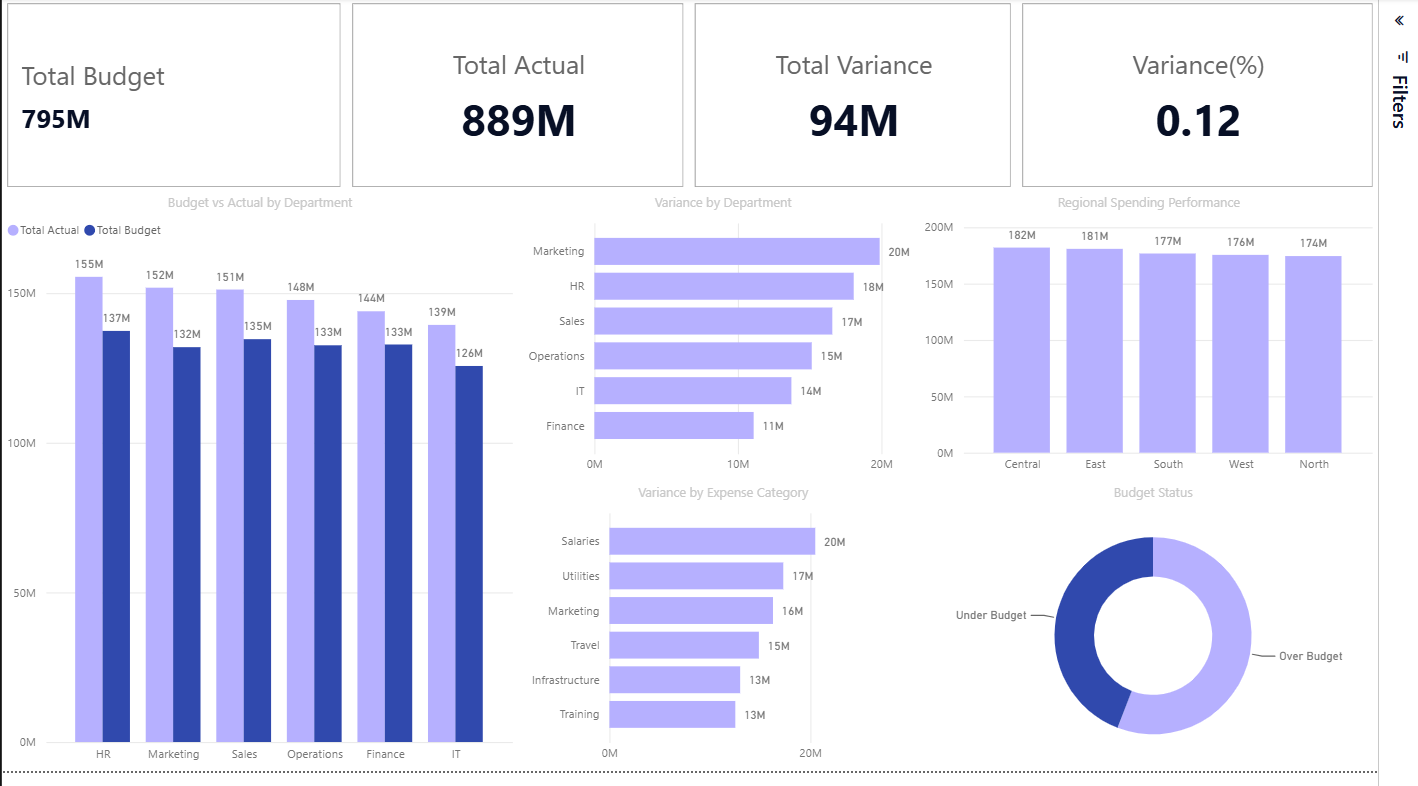